# 23 — Calibration & de-compression diagnostic

Stage-0 of [PLAN_Calibration.md](../PLAN_Calibration.md). Both deployed products
compress toward the middle; this notebook **characterizes** that compression for
each tier and **previews** the post-hoc, ranking-preserving fixes — the evidence
the plan is built on. Everything is group-aware leave-image-out (LOIO): the
calibrator is fit on the other 37 images and applied to the held-out one, via
`src.calibration.loio_calibrate`.

Headline (computed below): **Tier-1 is already well-calibrated** (ECE ≈ 0.06);
**Tier-2 quantile-matching recovers the true value distribution** (high tail +
true-zero mass) with ranking intact, while isotonic does not.


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(REPO))
from src.calibration import (reliability_curve, expected_calibration_error,
    TemperatureScaler, BetaCalibrator, IsotonicCalibrator, quantile_match,
    compression_metrics, loio_calibrate)

FIG = REPO / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
T1 = REPO / "models/fang_probe/fw_emb_mlp_ens3_gem96_S32_fa_gt_1e-2/predictions.parquet"
T2 = REPO / "models/fang_tier2/tier2_mlp_reg_emb_fractional_area_S32/1e01ad8b17447599/predictions.parquet"
t1 = pd.read_parquet(T1); t2 = pd.read_parquet(T2)
print(f"Tier-1 classifier preds: {len(t1):,} tiles, {t1.obs_id.nunique()} images")
print(f"Tier-2 mlp_reg preds:    {len(t2):,} tiles, {t2.obs_id.nunique()} images")


Tier-1 classifier preds: 161,005 tiles, 38 images
Tier-2 mlp_reg preds:    161,005 tiles, 38 images


## 1. Tier-1 — is the rich/poor probability compressed?

A reliability diagram bins tiles by predicted probability and plots the empirical
rich-rate against the bin's mean confidence; on the diagonal = calibrated, ECE is the
count-weighted gap. The raw classifier is mildly **over-dispersed**: above the
diagonal for p<0.5 (under-confident lows) and below for p>0.5 (over-confident highs).

We compare three calibrators (all LOIO, all monotone):
- **temperature scaling** — *one* global parameter (`p' = σ(logit(p)/T)`), strictly
  monotone so ROC-AUC is exact. But one knob can only squeeze uniformly toward 0.5,
  so it fixes the over-confident high end **at the cost of** the low end.
- **isotonic** — a *free* monotone map, so it can bend the two ends independently and
  fix both. **The best calibration here** (lowest ECE). Its flat steps create ties (a
  theoretical ranking risk), but with 161k tiles that cost is negligible — see the AUC
  note.
- **beta calibration** — a smooth 3-parameter *strictly*-monotone map
  ([Kull et al. 2017](https://proceedings.mlr.press/v54/kull17a.html)): no ties, but
  3 parameters underfit the reliability curve, so its ECE lands between temperature
  and isotonic. A smooth fallback if isotonic's step artifacts ever matter.

Note on AUC: a monotone map can't change ranking *within* an image, but the LOIO pool
fits a **different** map per held-out image, which reorders tiles *across* images and
dents the *pooled* AUC. At deployment a **single** global map is fit — AUC-exact for
all three (isotonic +0.0003, temperature/beta +0.0000) — so the LOIO pooled-AUC drop
is an artifact, not a real cost. Verdict: **isotonic** for Tier-1.


               variant    ECE  ECE_low  ECE_high  AUC_loio
                   raw  0.060    0.043     0.096    0.8484
  temperature (T=1.70)  0.049    0.063     0.021    0.8439
              isotonic  0.014    0.014     0.014    0.8331
                  beta  0.040    0.043     0.031    0.8354


global-fit AUC (deployment): temperature 0.8484  beta 0.8484  (raw 0.8484) -> LOIO drop is a per-fold artifact



Verdict: Tier-1 is near-calibrated; ISOTONIC fixes both ends best (ECE -> 0.014) and is AUC-exact at deployment. Beta is a smooth fallback; temperature trades the ends.


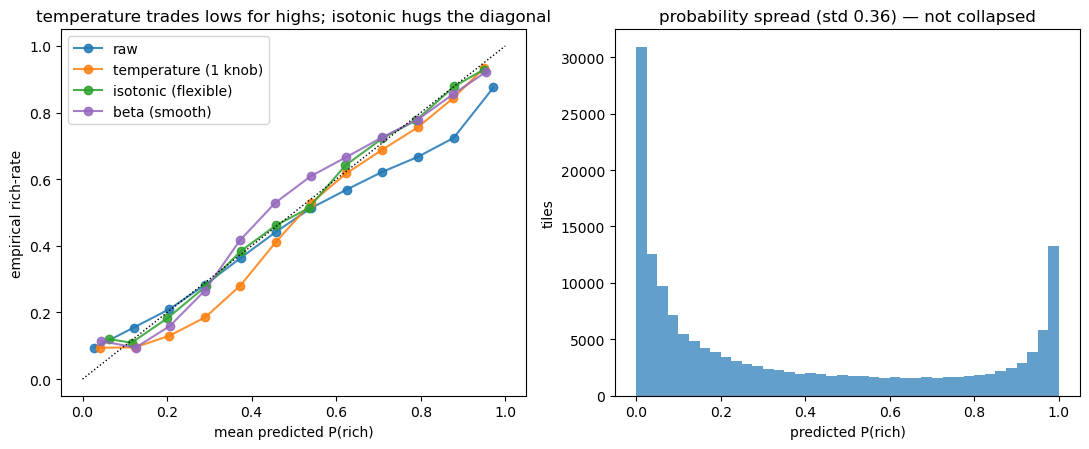

In [2]:
y = t1.y_true.to_numpy()

def ece_split(p):  # overall, lows(<0.5), highs(>=0.5)
    p = np.clip(p, 0, 1); lo = p < 0.5
    return (expected_calibration_error(y, p),
            expected_calibration_error(y[lo], p[lo]),
            expected_calibration_error(y[~lo], p[~lo]))

temp = loio_calibrate(t1, lambda rp, rt, hp: TemperatureScaler().fit(rp, rt).predict(hp))
iso  = loio_calibrate(t1, lambda rp, rt, hp: IsotonicCalibrator().fit(rp, rt).predict(hp))
beta = loio_calibrate(t1, lambda rp, rt, hp: BetaCalibrator().fit(rp, rt).predict(hp))
T_all = TemperatureScaler().fit(t1.y_pred.to_numpy(), y).T
rows = {"raw": t1.y_pred.to_numpy(), f"temperature (T={T_all:.2f})": temp,
        "isotonic": iso, "beta": beta}
print(f"{'variant':>22} {'ECE':>6} {'ECE_low':>8} {'ECE_high':>9} {'AUC_loio':>9}")
for n, p in rows.items():
    e, el, eh = ece_split(p)
    print(f"{n:>22} {e:>6.3f} {el:>8.3f} {eh:>9.3f} {roc_auc_score(y, np.clip(p,0,1)):>9.4f}")
# deployment case: ONE global map -> strictly-monotone calibrators are AUC-exact
gb = {n: c.fit(t1.y_pred.to_numpy(), y).predict(t1.y_pred.to_numpy())
      for n, c in [("temperature", TemperatureScaler()), ("beta", BetaCalibrator())]}
print("global-fit AUC (deployment): " + "  ".join(
    f"{n} {roc_auc_score(y, p):.4f}" for n, p in gb.items())
    + f"  (raw {roc_auc_score(y, t1.y_pred):.4f}) -> LOIO drop is a per-fold artifact")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for p, lbl, c in [(rows["raw"], "raw", "tab:blue"),
                  (temp, "temperature (1 knob)", "tab:orange"),
                  (iso, "isotonic (flexible)", "tab:green"),
                  (beta, "beta (smooth)", "tab:purple")]:
    conf, acc, _ = reliability_curve(y, np.clip(p, 0, 1), n_bins=12)
    ax[0].plot(conf, acc, "o-", color=c, label=lbl, alpha=0.85)
ax[0].plot([0, 1], [0, 1], "k:", lw=1)
ax[0].set_xlabel("mean predicted P(rich)"); ax[0].set_ylabel("empirical rich-rate")
ax[0].set_title("temperature trades lows for highs; isotonic hugs the diagonal"); ax[0].legend()
ax[1].hist(t1.y_pred, bins=40, color="tab:blue", alpha=0.7)
ax[1].set_xlabel("predicted P(rich)"); ax[1].set_ylabel("tiles")
ax[1].set_title(f"probability spread (std {t1.y_pred.std():.2f}) — not collapsed")
fig.tight_layout(); fig.savefig(FIG / "23_tier1_calibration.png", dpi=130)
print("\nVerdict: Tier-1 is near-calibrated; ISOTONIC fixes both ends best (ECE -> 0.014) "
      "and is AUC-exact at deployment. Beta is a smooth fallback; temperature trades the ends.")


## 2. Tier-2 — the two-sided compression

The abundance regressor minimizes MSE on a heavy-tailed, zero-inflated target under
a 5 m/px texture floor → it hedges to the conditional mean. The per-bin curve below
shows it **over-predicts the low end** (floors above true zero) and **under-predicts
the high tail**, crossing the diagonal near the rich/poor threshold; the marginal
histogram shows the predicted distribution is far narrower than the truth.


raw mlp_reg: spearman 0.651  top_ratio 0.714  near_zero pred 1.8% vs true 18.0%  marginal_L1 0.0057


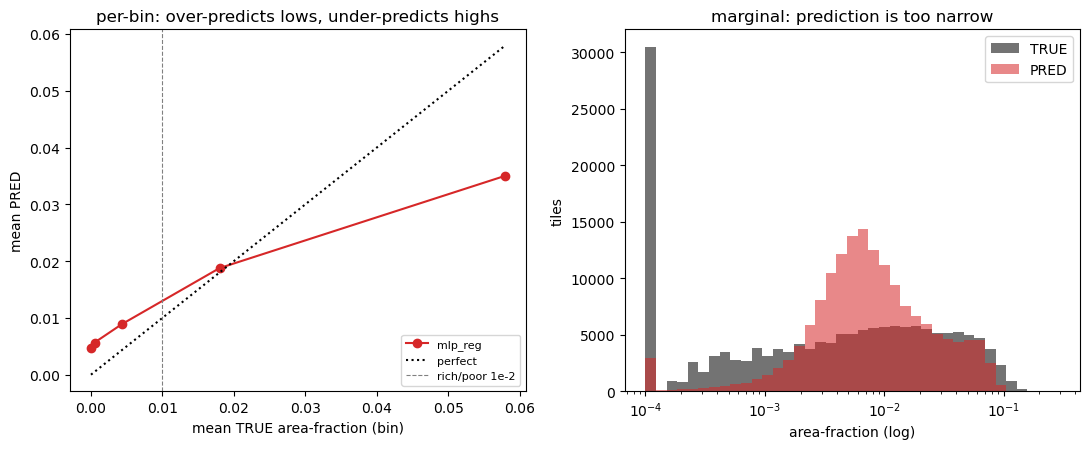

In [3]:
yt = t2.y_true.to_numpy(); yp = np.clip(t2.y_pred.to_numpy(), 0, None)
edges = np.array([0, 1e-4, 1e-3, 1e-2, 3e-2, 1.0])
lab = np.clip(np.digitize(yt, edges) - 1, 0, len(edges) - 2)
bt = np.array([yt[lab == b].mean() for b in range(len(edges) - 1)])
bp = np.array([yp[lab == b].mean() for b in range(len(edges) - 1)])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
ax[0].plot(bt, bp, "o-", color="tab:red", label="mlp_reg")
ax[0].plot([0, bt.max()], [0, bt.max()], "k:", label="perfect")
ax[0].axvline(1e-2, color="grey", ls="--", lw=0.8, label="rich/poor 1e-2")
ax[0].set_xlabel("mean TRUE area-fraction (bin)"); ax[0].set_ylabel("mean PRED")
ax[0].set_title("per-bin: over-predicts lows, under-predicts highs"); ax[0].legend(fontsize=8)
bins = np.logspace(-4, np.log10(max(yt.max(), 1e-3)), 40)
ax[1].hist(np.clip(yt, 1e-4, None), bins=bins, alpha=0.55, label="TRUE", color="k")
ax[1].hist(np.clip(yp, 1e-4, None), bins=bins, alpha=0.55, label="PRED", color="tab:red")
ax[1].set_xscale("log"); ax[1].set_xlabel("area-fraction (log)"); ax[1].set_ylabel("tiles")
ax[1].set_title("marginal: prediction is too narrow"); ax[1].legend()
fig.tight_layout(); fig.savefig(FIG / "23_tier2_compression.png", dpi=130)

m = compression_metrics(yt, yp)
print(f"raw mlp_reg: spearman {m['spearman']:.3f}  top_ratio {m['top_ratio']:.3f}  "
      f"near_zero pred {m['near_zero_pred']:.1%} vs true {m['near_zero_true']:.1%}  "
      f"marginal_L1 {m['marginal_l1']:.4f}")


## 3. Tier-2 — de-compression preview (LOIO)

Two monotone (ranking-preserving) post-hoc calibrators, fit on the other 37 images:
**isotonic** (fits pred→E[true]) and **quantile-matching** (maps the prediction
distribution onto the truth distribution). Quantile-matching recovers the marginal
by construction; isotonic fits the conditional mean — which *is* the compressed
quantity, so it cannot un-squash the tail.


### What is quantile-matching?

Quantile-matching (a.k.a. the quantile transform, or *histogram matching* in image
processing) replaces each prediction with the **truth value at the same rank**. Fit
on the training images:

1. Sort the training predictions and the training truths, separately.
2. Pair them by rank — smallest prediction ↦ smallest truth, median ↦ median,
   99th-percentile ↦ 99th-percentile, … — which defines a monotone lookup `g`.
3. At inference, push each new prediction `v` through `g`: find the fraction of
   training predictions it exceeds (its quantile), and emit the truth value at that
   quantile (linearly interpolated between the stored rank points).

In code this is just
`quantile_match(v) = np.interp(v, np.sort(ref_pred), np.sort(ref_true))`.

**Why it de-compresses.** By construction the calibrated outputs have the *same
distribution* as the truth — the same fraction of exact zeros and the same heavy
upper tail. The model's squashed range (~0.005–0.04) is stretched back onto the true
range (0–0.29). That is why, at right, the green marginal lands on the gray truth and
the 18% true-zero mass reappears.

**Why ranking is untouched.** `g` is non-decreasing, so it never reorders tiles — the
tile the model ranked highest stays highest. Spearman / NDCG / AUC are therefore
invariant (the small wobble here is only from fitting a *different* `g` per held-out
fold and pooling).

**What it cannot do (the honest limit).** It fixes the *distribution of values*, not
*which tile gets which value*. A genuinely high tile that the model mis-ranks into the
middle still receives a middle value, so the high per-bin point lands near — not on —
the diagonal (top-bin ratio ≈ 0.87). That residual is the ranking / aleatoric floor,
not calibration. And it matches the *global* cohort marginal, so it assumes a new
image resembles the cohort; a truly boulder-poor scene would have its lows wrongly
lifted — handled by fitting per-region or gating on the §2.7 novelty flag (see the
plan).


                  spearman  top_ratio  near_zero_pred  marginal_l1
raw mlp_reg          0.651      0.714           0.018        0.006
+ isotonic           0.627      0.704           0.000        0.008
+ quantile-match     0.644      0.874           0.186        0.000

(true near-zero share = 18.0%; goal: top_ratio->1, near_zero_pred->that, marginal_l1->0, spearman flat)


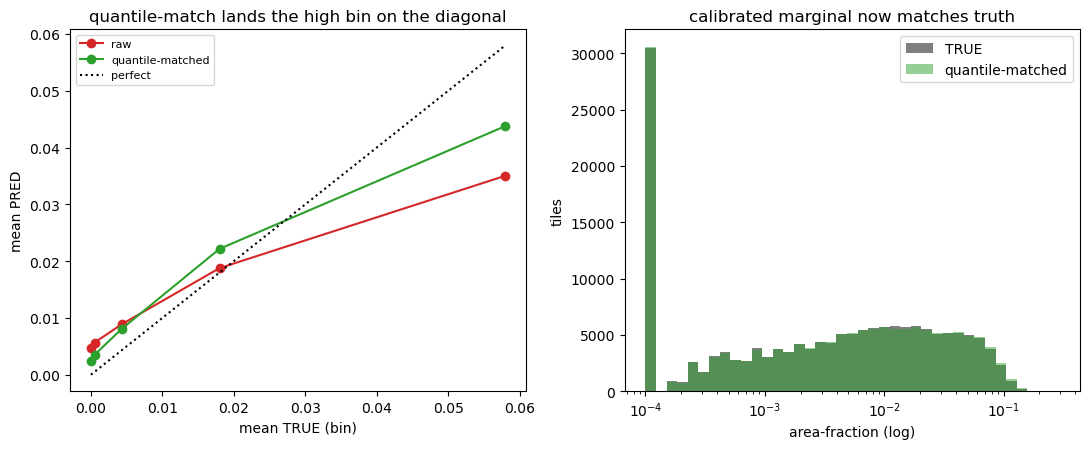

In [4]:
iso = loio_calibrate(t2, lambda rp, rt, hp: IsotonicCalibrator().fit(rp, rt).predict(hp))
qm  = loio_calibrate(t2, lambda rp, rt, hp: quantile_match(hp, rp, rt))
rows = {"raw mlp_reg": compression_metrics(yt, yp),
        "+ isotonic": compression_metrics(yt, iso),
        "+ quantile-match": compression_metrics(yt, qm)}
scorecard = pd.DataFrame(rows).T[["spearman", "top_ratio", "near_zero_pred", "marginal_l1"]]
print(scorecard.round(3).to_string())
print(f"\n(true near-zero share = {rows['raw mlp_reg']['near_zero_true']:.1%}; "
      "goal: top_ratio->1, near_zero_pred->that, marginal_l1->0, spearman flat)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for y, lbl, c in [(yp, "raw", "tab:red"), (qm, "quantile-matched", "tab:green")]:
    bp_ = np.array([np.clip(y, 0, None)[lab == b].mean() for b in range(len(edges) - 1)])
    ax[0].plot(bt, bp_, "o-", color=c, label=lbl)
ax[0].plot([0, bt.max()], [0, bt.max()], "k:", label="perfect")
ax[0].set_xlabel("mean TRUE (bin)"); ax[0].set_ylabel("mean PRED")
ax[0].set_title("quantile-match lands the high bin on the diagonal"); ax[0].legend(fontsize=8)
ax[1].hist(np.clip(yt, 1e-4, None), bins=bins, alpha=0.5, label="TRUE", color="k")
ax[1].hist(np.clip(qm, 1e-4, None), bins=bins, alpha=0.5, label="quantile-matched", color="tab:green")
ax[1].set_xscale("log"); ax[1].set_xlabel("area-fraction (log)"); ax[1].set_ylabel("tiles")
ax[1].set_title("calibrated marginal now matches truth"); ax[1].legend()
fig.tight_layout(); fig.savefig(FIG / "23_tier2_decompression.png", dpi=130)


## 4. What this tells the plan

- **Tier-1** is already well-calibrated (ECE ≈ 0.06, well-spread probabilities);
  temperature scaling is a small, safe refinement. *Not* the problem — the headline
  "mostly rich" maps over boulder-rich regions are largely correct.
- **Tier-2** compression is real and two-sided, and the banked structural variants
  (Tweedie, two-stage) compress *more*, not less — it is intrinsic to MSE-on-skewed
  + the texture floor.
- **Quantile-matching** is the Stage-1 win: it recovers the true value distribution
  (high tail + true-zero mass, marginal_L1 → 0) while preserving ranking. **Isotonic
  does not help** (it fits the compressed conditional mean).
- The residual (top-bin ratio ≈ 0.87, not 1.0) is the **ranking / aleatoric floor**:
  matching the marginal cannot place a mis-ranked high tile at the top. That residual
  is what the plan's later stages (better objectives; honest per-tile uncertainty)
  target. See [PLAN_Calibration.md](../PLAN_Calibration.md) for the staged plan and
  the marginal-vs-per-tile-vs-uncertainty framing.

Figures: `reports/figures/23_{tier1_calibration,tier2_compression,tier2_decompression}.png`.
